# VOC2007 evaluation
Computes the official VOC2007 11-point mAP@0.5 and integral AP@0.5.

In [4]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gt_guided_dino.api import evaluate_checkpoint
from gt_guided_dino.visualization import plot_predictions

In [5]:
METHOD = 'bqr_dn_v2'  # 'baseline', 'gt_guided_aux', or 'bqr_dn_v2'
checkpoint = PROJECT_ROOT / 'artifacts' / METHOD / 'seed_42' / 'checkpoints' / 'latest.pt'
result = evaluate_checkpoint(
    checkpoint,
    data_root=PROJECT_ROOT / 'VOC2007',
    precision='fp32',
)
result['metrics']

{'voc07_map50': 0.3927883734919668,
 'voc_map50_integral': 0.3792699109071876,
 'ap50_voc07_by_class': {'aeroplane': 0.5342186194043672,
  'bicycle': 0.40744504162736156,
  'bird': 0.5281498120238369,
  'boat': 0.3319481147449749,
  'bottle': 0.2352380854495,
  'bus': 0.3845820450940625,
  'car': 0.5143865950851794,
  'cat': 0.6208688406978539,
  'chair': 0.18322740779191823,
  'cow': 0.3636412711235732,
  'diningtable': 0.22438270601831045,
  'dog': 0.5322540464517228,
  'horse': 0.48503106607942253,
  'motorbike': 0.4430879949860863,
  'person': 0.4048392523739807,
  'pottedplant': 0.1635279910987075,
  'sheep': 0.23714263550613834,
  'sofa': 0.2916717511259994,
  'train': 0.5740055205335032,
  'tvmonitor': 0.3961186726228372},
 'ap50_integral_by_class': {'aeroplane': 0.5485080284237769,
  'bicycle': 0.3935410013484328,
  'bird': 0.5274873686030239,
  'boat': 0.31670420725464676,
  'bottle': 0.20083969727226625,
  'bus': 0.37708683998221504,
  'car': 0.5174331156309143,
  'cat': 0.63

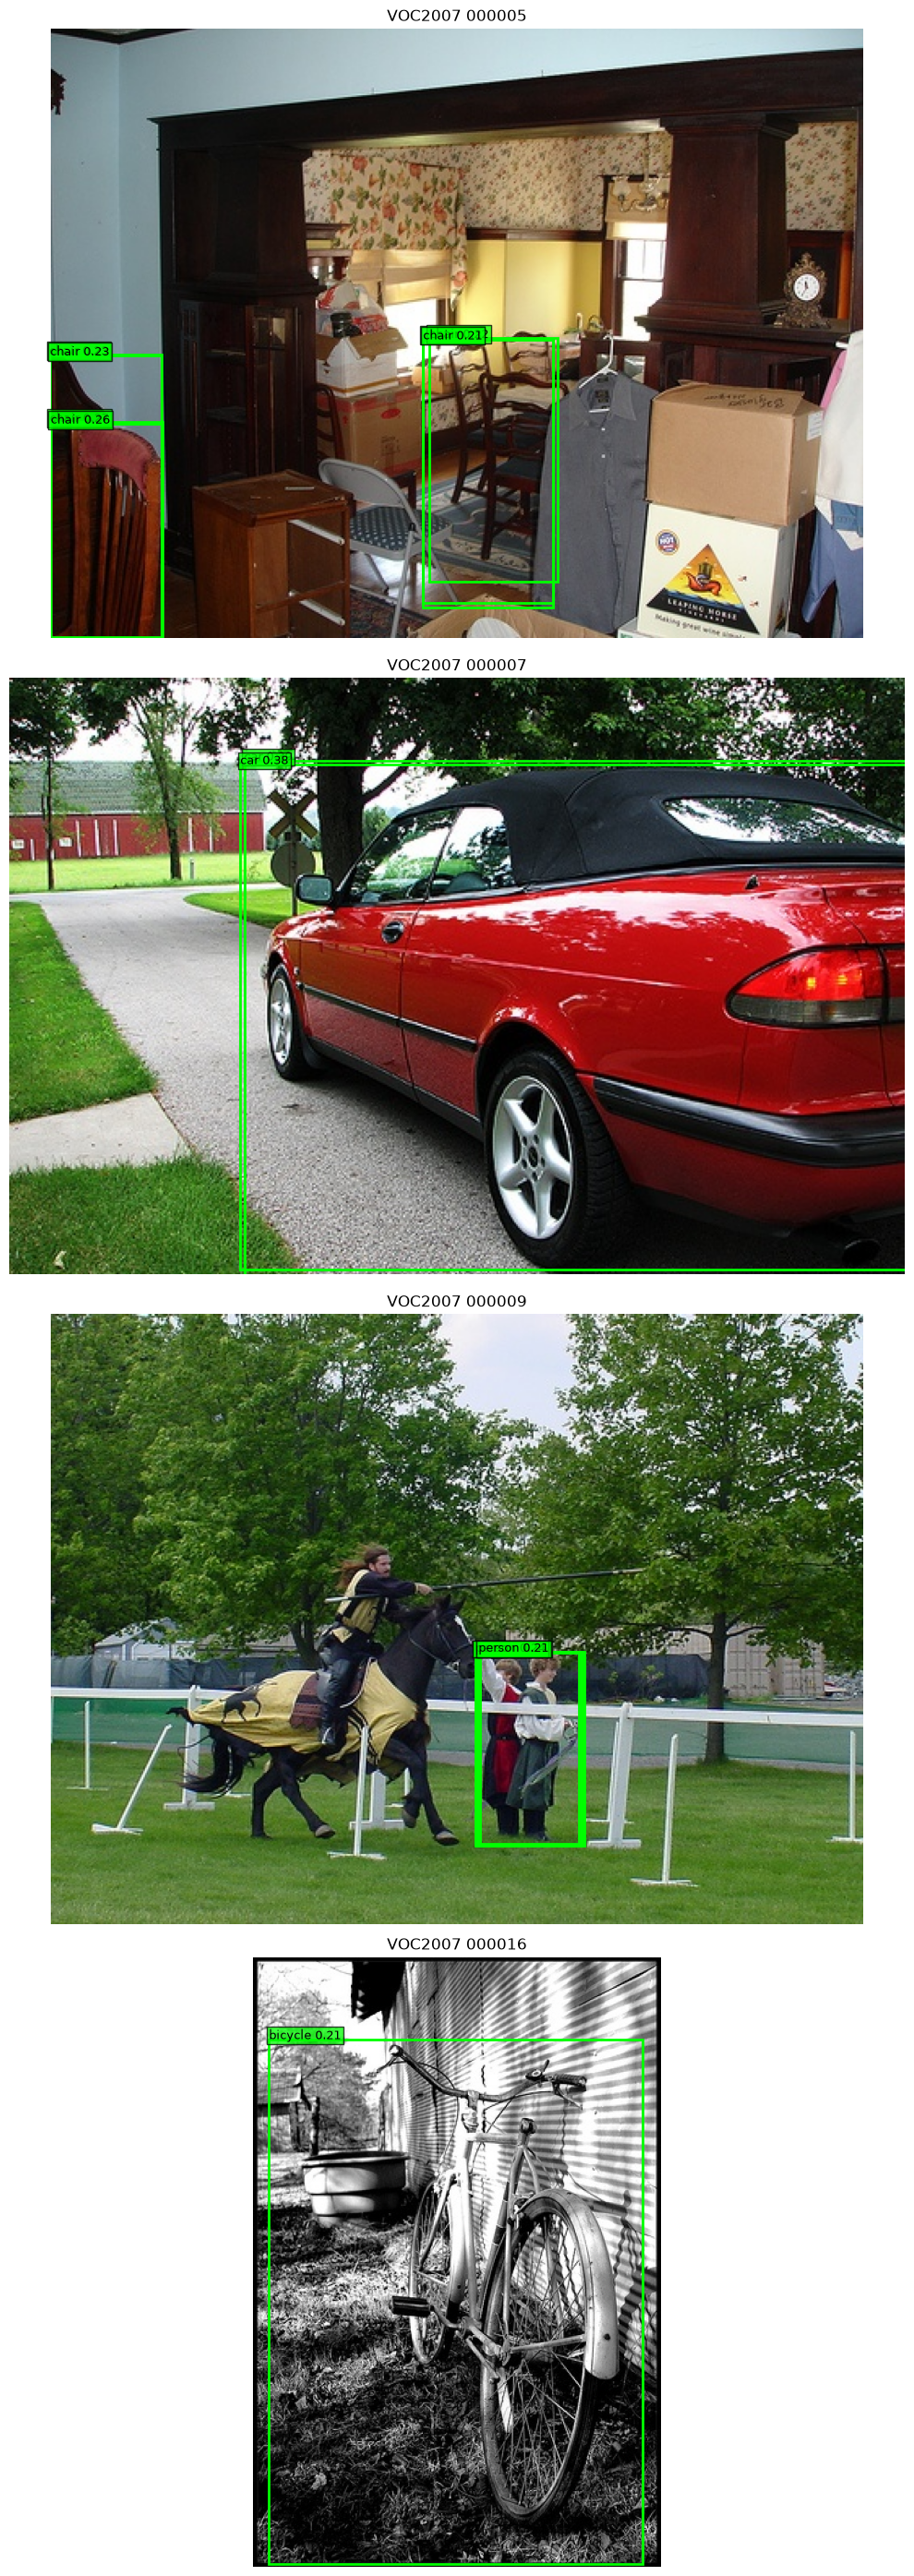

In [6]:
plot_predictions(
    result['predictions'],
    PROJECT_ROOT / 'VOC2007',
    count=4,
    score_threshold=0.2,
);